# Data Analysis Toolkit - Colab Version

**Student:** Christin Renni Philip  
**Student ID:** 100008781  
**Course:** Tools and Methods of Data Analysis  
**Sample Dataset:** Netflix Movies and TV Shows

Run each cell from top to bottom.

In [1]:
# ==========================================================
# SECTION 1: IMPORT REQUIRED LIBRARIES
# Purpose:
# Import all Python libraries needed for data analysis,
# visualization, probability distributions, and statistics.
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ==========================================================
# SECTION 2: IMPORT DATASET
# Purpose:
# Upload and load the sample CSV dataset into Google Colab.
# When asked, upload the file named: netflix_titles.csv
# ==========================================================

from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding="latin1")
df.head()


Saving netflix_titles.csv.zip to netflix_titles.csv.zip


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ==========================================================
# SECTION 3: DATA EXPLORATION
# Purpose:
# Explore the structure of the dataset including rows,
# columns, column names, data types, and general information.
# ==========================================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()


Rows: 8809
Columns: 26

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']

Data Types:


,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unname

In [4]:
# ==========================================================
# SECTION 4: MISSING VALUE ANALYSIS
# Purpose:
# Identify missing values and duplicate records.
# This helps understand the quality of the dataset.
# ==========================================================

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_table)

print("Duplicate rows:", df.duplicated().sum())


,Missing Values,Missing Percentage
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
director,2634,29.901237
cast,825,9.365422
country,831,9.433534
date_added,10,0.113520
release_year,0,0.000000
rating,4,0.045408
duration,3,0.034056


Duplicate rows: 0


In [5]:
# ==========================================================
# SECTION 5: DATA CLEANING AND PREPROCESSING
# Purpose:
# Remove duplicate rows and fill missing values.
# Numeric columns are filled using median.
# Categorical columns are filled using mode.
# ==========================================================

df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

numeric_cols = df_clean.select_dtypes(include=np.number).columns
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if not df_clean[col].mode().empty:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Data cleaning completed.")
print("Remaining missing values:", df_clean.isnull().sum().sum())

df_clean.head()


Data cleaning completed.
Remaining missing values: 123326


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,Rajiv Chilaka,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,Rajiv Chilaka,David Attenborough,United States,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,Rajiv Chilaka,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# ==========================================================
# SECTION 6: SELECT NUMERIC COLUMN
# Purpose:
# Select one numeric column for descriptive statistics,
# probability distribution analysis, and inference.
# For this Netflix dataset, use: release_year
# ==========================================================

numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

print("Available numeric columns:")
print(numeric_columns)

column_name = input("Enter numeric column name to analyze, example release_year: ")

data = df_clean[column_name].dropna()

print("Selected column:", column_name)
print("Number of values:", len(data))


Available numeric columns:
['release_year', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']
Enter numeric column name to analyze, example release_year: release_year
Selected column: release_year
Number of values: 8809


In [7]:
# ==========================================================
# SECTION 7: DESCRIPTIVE STATISTICS
# Purpose:
# Calculate summary measures such as mean, median,
# mode, standard deviation, variance, quartiles,
# skewness, and kurtosis.
# ==========================================================

summary_table = pd.DataFrame({
    "Statistic": [
        "Count", "Mean", "Median", "Mode",
        "Standard Deviation", "Variance",
        "Minimum", "Maximum", "Q1", "Q3",
        "Skewness", "Kurtosis"
    ],
    "Value": [
        data.count(),
        data.mean(),
        data.median(),
        data.mode()[0],
        data.std(),
        data.var(),
        data.min(),
        data.max(),
        data.quantile(0.25),
        data.quantile(0.75),
        data.skew(),
        data.kurtosis()
    ]
})

display(summary_table)


,Statistic,Value
0,Count,8809.000000
1,Mean,2014.181292
2,Median,2017.000000
3,Mode,2018.000000
4,Standard Deviation,8.818932
5,Variance,77.773556
6,Minimum,1925.000000
7,Maximum,2024.000000
8,Q1,2013.000000
9,Q3,2019.000000


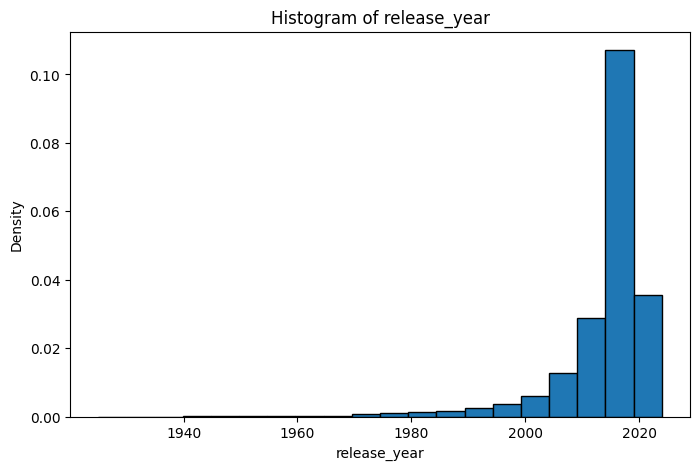

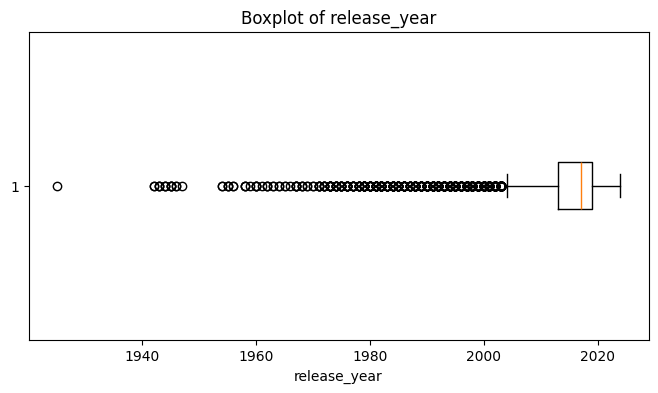

In [8]:
# ==========================================================
# SECTION 8: DATA VISUALIZATION
# Purpose:
# Create histogram and boxplot to understand distribution,
# spread, central tendency, and possible outliers.
# ==========================================================

plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, edgecolor="black", density=True)
plt.title("Histogram of " + column_name)
plt.xlabel(column_name)
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(data, vert=False)
plt.title("Boxplot of " + column_name)
plt.xlabel(column_name)
plt.show()


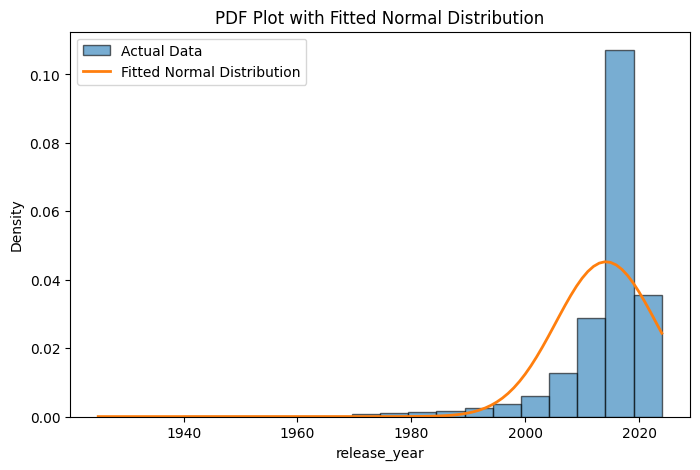

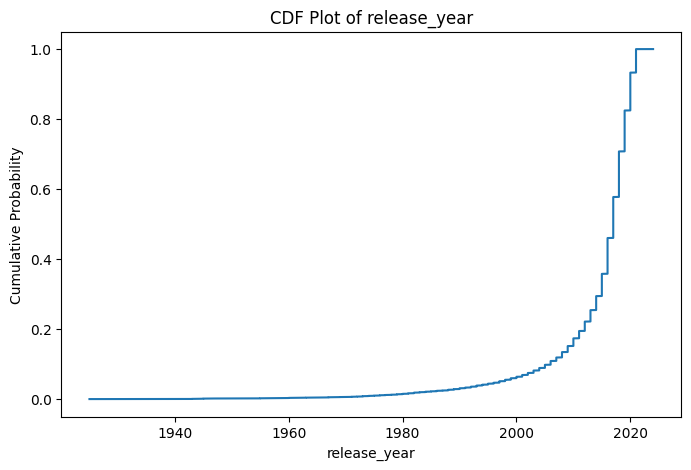

In [9]:
# ==========================================================
# SECTION 9: PROBABILITY DISTRIBUTION ANALYSIS
# Purpose:
# Compare the actual data with a fitted normal distribution
# using PDF and CDF plots.
# ==========================================================

mean = data.mean()
std = data.std()

x = np.linspace(data.min(), data.max(), 100)
normal_pdf = stats.norm.pdf(x, mean, std)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, edgecolor="black", label="Actual Data")
plt.plot(x, normal_pdf, linewidth=2, label="Fitted Normal Distribution")
plt.title("PDF Plot with Fitted Normal Distribution")
plt.xlabel(column_name)
plt.ylabel("Density")
plt.legend()
plt.show()

sorted_data = np.sort(data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

plt.figure(figsize=(8, 5))
plt.plot(sorted_data, cdf)
plt.title("CDF Plot of " + column_name)
plt.xlabel(column_name)
plt.ylabel("Cumulative Probability")
plt.show()


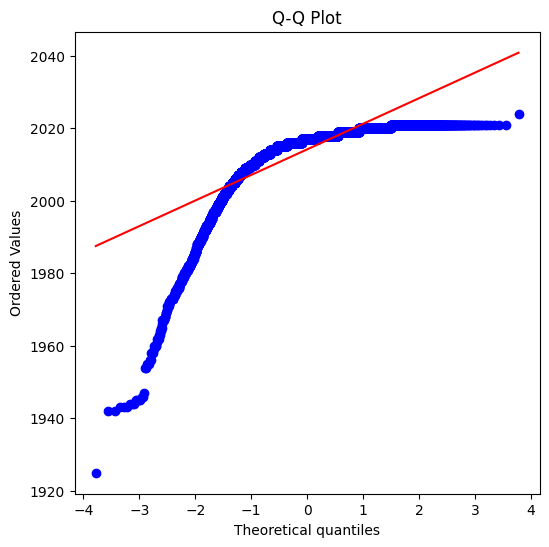

In [10]:
# ==========================================================
# SECTION 10: Q-Q PLOT ANALYSIS
# Purpose:
# Visually check whether the selected numeric data follows
# a normal distribution.
# ==========================================================

plt.figure(figsize=(6, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()


In [11]:
# ==========================================================
# SECTION 11: NORMALITY TESTING
# Purpose:
# Perform Shapiro-Wilk, Kolmogorov-Smirnov, and
# Anderson-Darling tests.
#
# H0: Data follows a normal distribution.
# H1: Data does not follow a normal distribution.
# ==========================================================

alpha = 0.05

# Shapiro-Wilk can warn for very large samples, but it is still useful for demonstration.
shapiro = stats.shapiro(data)
ks = stats.kstest(data, "norm", args=(data.mean(), data.std()))
anderson = stats.anderson(data, dist="norm")

normality_table = pd.DataFrame({
    "Test": ["Shapiro-Wilk", "Kolmogorov-Smirnov", "Anderson-Darling"],
    "Statistic": [shapiro.statistic, ks.statistic, anderson.statistic],
    "p-value / Info": [shapiro.pvalue, ks.pvalue, "Compare statistic with critical value"],
    "Null Hypothesis": ["Data is normally distributed"] * 3,
    "Alternative Hypothesis": ["Data is not normally distributed"] * 3
})

display(normality_table)

print("Shapiro-Wilk decision:")
print("Fail to reject H0" if shapiro.pvalue > alpha else "Reject H0")

print("\nKolmogorov-Smirnov decision:")
print("Fail to reject H0" if ks.pvalue > alpha else "Reject H0")

print("\nAnderson-Darling details:")
print("Statistic:", anderson.statistic)
print("Critical values:", anderson.critical_values)
print("Significance levels:", anderson.significance_level)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8809.
  res = hypotest_fun_out(*samples, **kwds)


,Test,Statistic,p-value / Info,Null Hypothesis,Alternative Hypothesis
0,Shapiro-Wilk,0.639549,0.0,Data is normally distributed,Data is not normally distributed
1,Kolmogorov-Smirnov,0.242738,0.0,Data is normally distributed,Data is not normally distributed
2,Anderson-Darling,888.207849,Compare statistic with critical value,Data is normally distributed,Data is not normally distributed


Shapiro-Wilk decision:
Reject H0

Kolmogorov-Smirnov decision:
Reject H0

Anderson-Darling details:
Statistic: 888.2078486798273
Critical values: [0.576 0.656 0.787 0.918 1.092]
Significance levels: [15.  10.   5.   2.5  1. ]


In [12]:
# ==========================================================
# SECTION 12: CONFIDENCE INTERVAL ESTIMATION
# Purpose:
# Calculate a 95% confidence interval for the population
# mean of the selected numeric column.
# ==========================================================

confidence = 0.95

sample_mean = data.mean()
standard_error = stats.sem(data)

ci = stats.t.interval(
    confidence,
    len(data) - 1,
    loc=sample_mean,
    scale=standard_error
)

print("Sample mean:", sample_mean)
print("95% Confidence Interval:", ci)


Sample mean: 2014.1812918605972
95% Confidence Interval: (np.float64(2013.99710423639), np.float64(2014.3654794848044))


In [13]:
# ==========================================================
# SECTION 13: HYPOTHESIS TESTING
# Purpose:
# Perform a one-sample t-test to compare the sample mean
# against a hypothesized value.
#
# H0: Sample mean equals the hypothesized mean.
# H1: Sample mean is different from the hypothesized mean.
# ==========================================================

hypothesized_mean = float(input("Enter hypothesized mean value, example 2015: "))

t_result = stats.ttest_1samp(data, hypothesized_mean)

print("H0: Mean =", hypothesized_mean)
print("H1: Mean !=", hypothesized_mean)
print("T-statistic:", t_result.statistic)
print("p-value:", t_result.pvalue)

if t_result.pvalue > alpha:
    print("Decision: Fail to reject H0")
    print("Conclusion: The sample mean is not significantly different from the hypothesized mean.")
else:
    print("Decision: Reject H0")
    print("Conclusion: The sample mean is significantly different from the hypothesized mean.")


Enter hypothesized mean value, example 2015: 2015
H0: Mean = 2015.0
H1: Mean != 2015.0
T-statistic: -8.713174989960814
p-value: 3.491588802178308e-18
Decision: Reject H0
Conclusion: The sample mean is significantly different from the hypothesized mean.


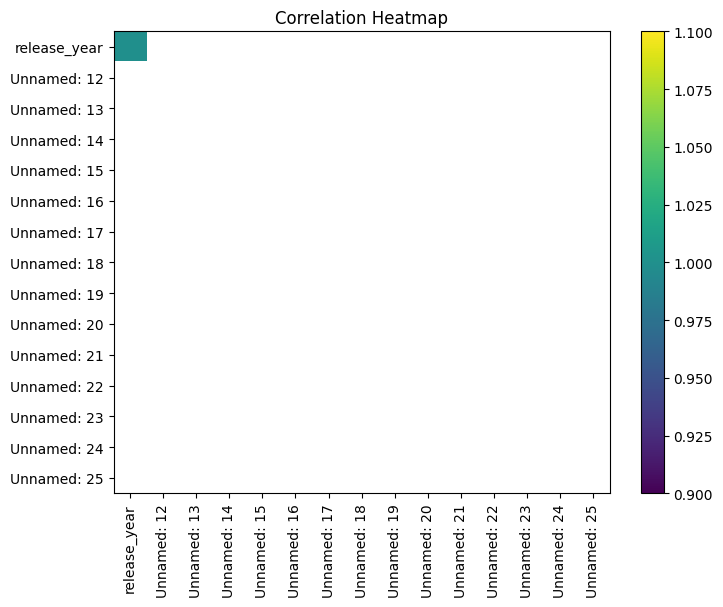

In [14]:
# ==========================================================
# SECTION 14: CORRELATION ANALYSIS
# Purpose:
# Create a correlation heatmap to check relationships
# between numeric variables.
# ==========================================================

numeric_df = df_clean.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("This dataset does not have enough numeric columns for correlation analysis.")


In [15]:
# ==========================================================
# SECTION 15: EXPORT CLEANED DATASET
# Purpose:
# Save the cleaned dataset so it can be reused,
# downloaded, or submitted with the analysis.
# ==========================================================

df_clean.to_csv("cleaned_netflix_dataset.csv", index=False)

print("Cleaned dataset exported as cleaned_netflix_dataset.csv")


Cleaned dataset exported as cleaned_netflix_dataset.csv


## Final Toolkit Conclusion

This toolkit provides a complete workflow for data exploration, missing-value analysis, data cleaning, descriptive statistics, visualization, probability distribution analysis, Q-Q plot analysis, normality testing, confidence interval estimation, hypothesis testing, correlation analysis, and exporting cleaned data. It is designed to be reusable and beginner-friendly.